In [11]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

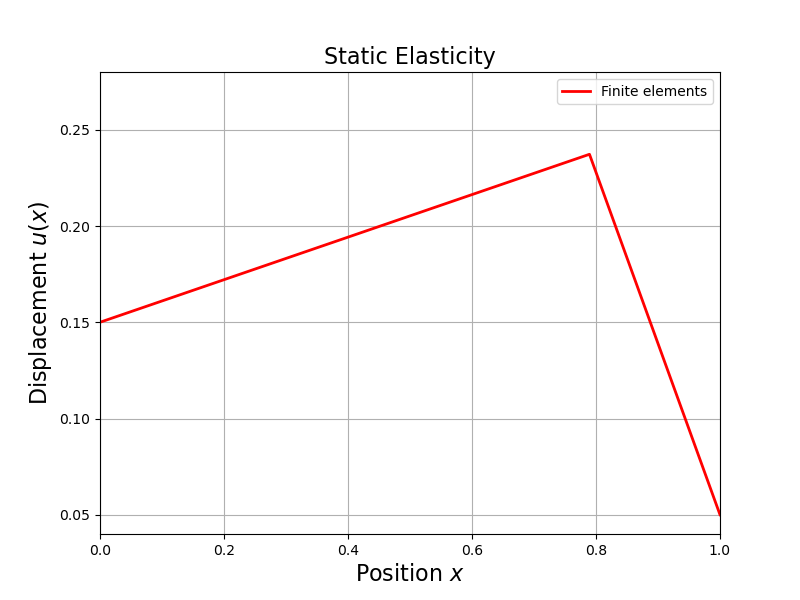

In [12]:
# ---------------------------------------------------------------
# Initialization of setup
# ---------------------------------------------------------------
nx = 20              # Number of element boundary points
u  = np.zeros(nx)    # Solution vector 
f  = np.zeros(nx)    # Source vector 
mu = 1               # Constant shear modulus 

# Element boundary points
x = np.linspace(0, 1, nx)  # x in [0,1]
h = x[2] - x[1]            # Constant element size

# ---------------------------------------------------------------
# Assemble stiffness matrix K_ij
# ---------------------------------------------------------------
K = np.zeros((nx, nx))
for i in range(1, nx-1):
    for j in range(1, nx-1):
        if i == j:
            K[i, j] = 2*mu/h
        elif i == j + 1:
            K[i, j] = -mu/h
        elif i + 1 == j:
            K[i, j] = -mu/h
        else:
            K[i, j] = 0

# ---------------------------------------------------------------
# Souce term is a spike at i = 3*nx/4
f[int(3*nx/4)] = 1

# Boundary condition at x = 0
u[0] = 0.15 ; f[1] = u[0]/h

# Boundary condition at x = 1
u[nx-1] = 0.05 ; f[nx-2] = u[nx-1]/h

# ---------------------------------------------------------------
# Finite element solution
# ---------------------------------------------------------------
u[1:nx-1] = np.linalg.inv(K[1:nx-1, 1:nx-1]) @ np.transpose(f[1:nx-1]) 

# ---------------------------------------------------------------
# Plotting section
# ---------------------------------------------------------------
plt.figure(figsize=(8,6))

xfe = u 
plt.plot(x, xfe, color='r', lw=2, label='Finite elements')
plt.title('Static Elasticity', size=16)
plt.ylabel('Displacement $u(x)$', size=16)
plt.xlabel('Position $x$', size=16)
plt.axis([0, 1, 0.04, .28])
plt.legend()
plt.grid(True)
plt.show()

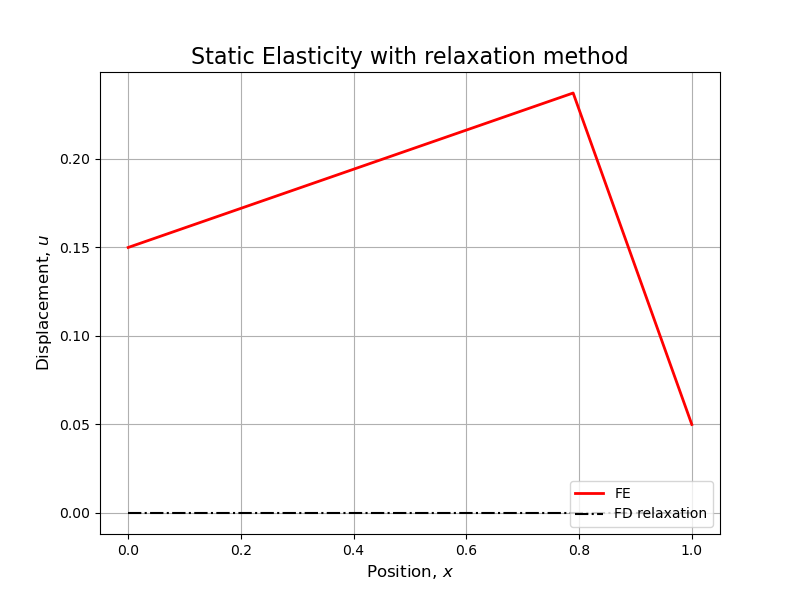

In [13]:
# Poisson's equation with relaxation method
# ---------------------------------------------------------------
nt = 500     # Number of iterations
iplot = 2   # Snapshot frequency

# non-zero boundary conditions
u  = np.zeros(nx)   # set u to zero
du = np.zeros(nx)   # du/dx
f  = np.zeros(nx)   # forcing

f[int(3*nx/4)] = 1./h

xfd = np.arange(0, nx)*h

# ---------------------------------------------------------------
# Initialize animated plot
# ---------------------------------------------------------------
plt.figure(figsize=(8,6))

line1 = plt.plot(x, xfe, color='r', lw=2, label='FE') 
line2 = plt.plot(xfd, u, color='k', ls='-.', label='FD relaxation')
plt.title('Static Elasticity with relaxation method', size=16)
plt.ylabel('Displacement, $u$', size=12)
plt.xlabel('Position, $x$', size=12)
plt.legend(loc=4)
plt.grid(True)

plt.ion()   # set interective mode
plt.show()
# ---------------------------------------------------------------
for it in range(nt):
    # Calculate the average of u (omit boundaries)
    for i in range(1, nx-1):
        du[i] =u [i+1] + u[i-1]
    u = 0.5*( f*h**2/mu + du )
    u[0] = 0.15    # Boundary condition at x=0
    u[nx-1] = 0.05 # Boundary condition at x=1
    fd = u
    
    # --------------------------------------   
    # Animation plot. Display both solutions
    if not it % iplot:
        for l in line2:
            l.remove()
            del l        
        line1 = plt.plot(x, xfe, color='r', lw=2)
        line2 = plt.plot(xfd, fd, color='k', ls='-.')
        plt.gcf().canvas.draw()    